In [ ]:
"""
FIXED: NetLogo vs GAMA Validation Analysis
Handles specific header formats described by user
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import csv

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# 1. FIXED DATA LOADING
# ============================================================================

def load_netlogo_data(filepath):
    """Load NetLogo BehaviorSpace output with specific mapping"""
    print(f"Loading NetLogo data from {filepath}...")
    
    try:
        # Detect header row (looking for '[run number]')
        header_row = 0
        with open(filepath, 'r') as f:
            for i, line in enumerate(f):
                if '[run number]' in line or '"[run number]"' in line:
                    header_row = i
                    break
        
        print(f"  Found header at row {header_row}")
        
        # Load csv
        df = pd.read_csv(filepath, skiprows=header_row)
        
        # Clean column names
        df.columns = df.columns.str.replace('"', '').str.strip()
        
        print(f"  Original columns: {list(df.columns)}")
        
        # Specific Mapping based on your NetLogo file
        rename_map = {
            '[run number]': 'run',
            '[step]': 'cycle',
            'count beetle': 'beetles',
            'sum [Totmeter] of patches': 'wood_damage', 
            'run number': 'run', # Fallback
            'step': 'cycle'      # Fallback
        }
        
        # Apply mapping
        df = df.rename(columns=rename_map)
        
        # Keep only relevant columns
        keep_cols = ['run', 'cycle', 'beetles', 'wood_damage']
        available_cols = [c for c in keep_cols if c in df.columns]
        df = df[available_cols]
        
        print(f"  Mapped columns: {list(df.columns)}")
        print(f"  Loaded {len(df)} rows, {df['run'].nunique()} unique runs")
        
        return df
        
    except Exception as e:
        print(f"  ERROR loading NetLogo: {e}")
        return None

def load_gama_data(filepath):
    """Load GAMA output handling the double header issue"""
    print(f"Loading GAMA data from {filepath}...")
    
    try:
        # Check first few lines to handle the specific 'Zeile 1' vs 'Zeile 2' issue
        with open(filepath, 'r') as f:
            lines = [f.readline() for _ in range(5)]
            
        # Strategy: GAMA usually puts the clean header on the 2nd line if rewrite:true was used awkwardly
        # or if the first line is string-formatted.
        
        # If line 0 contains single quotes 'run_id' and line 1 is clean run_id,step...
        # We should skip row 0 and use row 1 as header
        skip_rows = 0
        if "'" in lines[0] and "run_id" in lines[0] and "run_id" in lines[1]:
            print("  Detected double header (GAMA string format), skipping first line.")
            skip_rows = 1
            
        df = pd.read_csv(filepath, skiprows=skip_rows)
        
        # If we accidentally read the second header as a data row (because we didn't skip enough),
        # pandas might treat "run_id" as a value in the dataframe. Let's clean that.
        # Check if the first row values equal the column names
        if df.iloc[0,0] == df.columns[0] or str(df.iloc[0,0]) == 'run_id':
            print("  Detected header inside data, dropping first row.")
            df = df.iloc[1:]
            
        # Ensure numeric types
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
        df = df.dropna()

        # Rename to standard names
        rename_map = {
            'run_id': 'run',
            'step': 'cycle',
            # 'beetles' is already 'beetles'
            # 'wood_damage' is already 'wood_damage'
        }
        df = df.rename(columns=rename_map)
        
        print(f"  Columns: {list(df.columns)}")
        print(f"  Loaded {len(df)} rows, {df['run'].nunique()} unique runs")
        
        return df

    except Exception as e:
        print(f"  ERROR loading GAMA: {e}")
        return None

# ============================================================================
# 2. ANALYSIS & PLOTTING
# ============================================================================

def compare_models(nl_df, gama_df, output_dir='validation_results'):
    Path(output_dir).mkdir(exist_ok=True)
    
    # 1. Align Data by Cycle
    # Get common cycle range
    max_cycle = min(nl_df['cycle'].max(), gama_df['cycle'].max())
    print(f"\nAligning data up to cycle {max_cycle}...")
    
    nl_df = nl_df[nl_df['cycle'] <= max_cycle]
    gama_df = gama_df[gama_df['cycle'] <= max_cycle]
    
    # 2. Compute Statistics (Mean & Std per cycle)
    metrics = ['beetles', 'wood_damage']
    
    for metric in metrics:
        if metric not in nl_df.columns or metric not in gama_df.columns:
            print(f"Skipping {metric} (missing in data)")
            continue
            
        print(f"Analyzing {metric}...")
        
        # Group by cycle
        nl_stats = nl_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        gama_stats = gama_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        
        # 3. Calculate Correlation (Pearson)
        # We correlate the MEAN behavior of both models
        r, p = stats.pearsonr(nl_stats['mean'], gama_stats['mean'])
        rmse = np.sqrt(((nl_stats['mean'] - gama_stats['mean']) ** 2).mean())
        
        print(f"  Pearson Correlation: r={r:.4f} (p={p:.4e})")
        print(f"  RMSE: {rmse:.2f}")
        
        # 4. Plot
        plt.figure(figsize=(12, 6))
        
        # NetLogo (Blue)
        plt.plot(nl_stats['cycle'], nl_stats['mean'], label=f'NetLogo (r={r:.2f})', color='blue', linewidth=2)
        plt.fill_between(nl_stats['cycle'], 
                         nl_stats['mean'] - nl_stats['std'], 
                         nl_stats['mean'] + nl_stats['std'], 
                         color='blue', alpha=0.2)
        
        # GAMA (Red)
        plt.plot(gama_stats['cycle'], gama_stats['mean'], label='GAMA', color='red', linestyle='--', linewidth=2)
        plt.fill_between(gama_stats['cycle'], 
                         gama_stats['mean'] - gama_stats['std'], 
                         gama_stats['mean'] + gama_stats['std'], 
                         color='red', alpha=0.2)
        
        plt.title(f'Model Validation: {metric.replace("_", " ").title()}', fontsize=14)
        plt.xlabel('Simulation Steps (Ticks)', fontsize=12)
        plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Save
        filename = f"{output_dir}/validation_{metric}.png"
        plt.savefig(filename, dpi=300)
        print(f"  Saved plot to {filename}")
        plt.close()

# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    # FILE PATHS - Check these match your files!
    netlogo_file = "netlogo_results1.csv" # Dein NetLogo File
    gama_file = "gama_results2.csv"       # Dein GAMA File
    
    print("--- STARTING VALIDATION ---")
    
    nl_data = load_netlogo_data(netlogo_file)
    gama_data = load_gama_data(gama_file)
    
    if nl_data is not None and gama_data is not None:
        compare_models(nl_data, gama_data)
        print("\n--- VALIDATION COMPLETE ---")
    else:
        print("\n--- FAILED TO LOAD DATA ---")

--- STARTING VALIDATION ---
Loading NetLogo data from netlogo_results1.csv...
  Found header at row 6
  Original columns: ['[run number],Windwurf,todeschance,Management,Beetleonpatch,Klimakrise,maxbeetles,Extremevent,Managementnumber,tempvalue,[step],count beetle,sum [Totmeter] of patches']
  Mapped columns: []
  ERROR loading NetLogo: 'run'
Loading GAMA data from gama_results2.csv...
  Detected double header (GAMA string format), skipping first line.
  Columns: ['run', 'cycle', 'beetles', 'wood_damage']
  Loaded 168132 rows, 10 unique runs

--- FAILED TO LOAD DATA ---


In [7]:
"""
FIXED v8.1: NetLogo vs GAMA Validation
Includes a 'Line Cleaner' to fix double-quoted CSV formats.
Now displays plots inline before saving them in high scientific quality.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys
import os
import io

# Setup - Scientific Paper Style (IEEE)
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.size': 12,
    'font.family': 'serif', # Serifenschrift für akademischen Look
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 12
})

def debug_print(msg):
    print(msg)
    sys.stdout.flush()

# ============================================================================
# 1. SPECIALIZED NETLOGO LOADER
# ============================================================================

def load_netlogo_data(filepath):
    debug_print(f"\n--- Loading NetLogo: {filepath} ---")
    if not os.path.exists(filepath): return None

    # --- STEP 1: READ AND CLEAN RAW LINES MANUALLY ---
    cleaned_csv_buffer = io.StringIO()
    
    header_found = False
    row_count = 0
    
    try:
        with open(filepath, 'r', encoding='latin-1') as f:
            for line in f:
                line = line.strip()
                
                # 1. Skip garbage lines at the start until we find the header
                if not header_found:
                    if '[run number]' in line:
                        header_found = True
                        debug_print("  > Found header row. Starting cleanup...")
                    else:
                        continue 
                
                # 2. THE FIX: Strip outer quotes and fix double-double quotes
                if line.startswith('"') and line.endswith('"'):
                    line = line[1:-1]             
                    line = line.replace('""', '"') 
                
                # 3. Write clean line to our memory buffer
                cleaned_csv_buffer.write(line + "\n")
                row_count += 1
                
        debug_print(f"  > Cleaned {row_count} rows in memory.")
        cleaned_csv_buffer.seek(0)
        
    except Exception as e:
        debug_print(f"  ERROR reading file: {e}")
        return None

    if row_count == 0:
        debug_print("  CRITICAL: No relevant data found (Header '[run number]' never matched).")
        return None

    # --- STEP 2: LOAD FROM CLEANED MEMORY BUFFER ---
    try:
        df = pd.read_csv(cleaned_csv_buffer, sep=',')
        
        # Clean up column names
        df.columns = df.columns.str.replace('[', '').str.replace(']', '').str.replace('"', '').str.strip()
        debug_print(f"  > Detected Columns: {list(df.columns)}")

        # --- STEP 3: MAP COLUMNS ---
        rename_map = {
            'run number': 'run',
            'step': 'cycle',
            'count beetle': 'beetles',
            'sum Totmeter of patches': 'wood_damage',
            'Totmeter': 'wood_damage',
            'wood_damage': 'wood_damage'
        }
        df = df.rename(columns=rename_map)

        # --- STEP 4: FILTER AND CONVERT ---
        req_cols = ['run', 'cycle', 'beetles', 'wood_damage']
        available = [c for c in req_cols if c in df.columns]
        df = df[available]
        
        # Force Numeric
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
        df = df.dropna()
        
        debug_print(f"  > SUCCESS: Loaded {len(df)} rows.")
        return df

    except Exception as e:
        debug_print(f"  ERROR parsing cleaned data: {e}")
        return None

# ============================================================================
# 2. GAMA LOADER (Standard)
# ============================================================================

def load_gama_data(filepath):
    debug_print(f"\n--- Loading GAMA: {filepath} ---")
    if not os.path.exists(filepath): return None
        
    try:
        skip_count = 0
        with open(filepath, 'r', encoding='latin-1') as f:
            l1 = f.readline()
            l2 = f.readline()
            if "'" in l1 and "run_id" in l1 and "run_id" in l2:
                skip_count = 1
        
        df = pd.read_csv(filepath, skiprows=skip_count)
        if len(df) > 0 and str(df.iloc[0,0]) == 'run_id': df = df.iloc[1:]

        df = df.rename(columns={'run_id': 'run', 'step': 'cycle'})
        
        cols = ['run', 'cycle', 'beetles', 'wood_damage']
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        df = df.dropna()
        debug_print(f"  > Loaded {len(df)} rows.")
        return df

    except Exception as e:
        debug_print(f"  ERROR loading GAMA: {e}")
        return None

# ============================================================================
# 3. ANALYSIS & PLOTTING
# ============================================================================

def compare_models(nl_df, gama_df, output_dir='validation_results'):
    debug_print("\n--- Starting Comparison ---")
    Path(output_dir).mkdir(exist_ok=True)
    
    # Align
    max_cycle = min(nl_df['cycle'].max(), gama_df['cycle'].max())
    debug_print(f"  > Aligning data up to cycle {max_cycle}")
    
    nl_df = nl_df[nl_df['cycle'] <= max_cycle]
    gama_df = gama_df[gama_df['cycle'] <= max_cycle]
    
    metrics = ['beetles', 'wood_damage']
    
    for metric in metrics:
        debug_print(f"\n  Analyzing {metric}...")
        
        if metric not in nl_df.columns:
            debug_print(f"  MISSING in NetLogo: {metric}")
            continue
        if metric not in gama_df.columns:
            debug_print(f"  MISSING in GAMA: {metric}")
            continue
            
        nl_stats = nl_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        gama_stats = gama_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        
        # Stats
        r, p, rmse = 0, 0, 0
        if len(nl_stats) > 1 and len(gama_stats) > 1:
            if nl_stats['mean'].std() > 0 and gama_stats['mean'].std() > 0:
                r, p = stats.pearsonr(nl_stats['mean'], gama_stats['mean'])
            rmse = np.sqrt(((nl_stats['mean'] - gama_stats['mean']) ** 2).mean())
        
        debug_print(f"    Pearson r={r:.4f} | RMSE={rmse:.2f}")
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # NetLogo Plot (Blue)
        ax.plot(nl_stats['cycle'], nl_stats['mean'], label=f'NetLogo', color='#1f77b4', linewidth=2.5)
        ax.fill_between(nl_stats['cycle'], nl_stats['mean'] - nl_stats['std'], nl_stats['mean'] + nl_stats['std'], color='#1f77b4', alpha=0.2)
        
        # GAMA Plot (Red)
        ax.plot(gama_stats['cycle'], gama_stats['mean'], label='GAMA', color='#d62728', linestyle='--', linewidth=2.5)
        ax.fill_between(gama_stats['cycle'], gama_stats['mean'] - gama_stats['std'], gama_stats['mean'] + gama_stats['std'], color='#d62728', alpha=0.2)
        
        # Clean labels and title
        formatted_metric_name = "Beetle Population (Count)" if metric == 'beetles' else "Cumulative Timber Damage [m³]"
        ax.set_title(f'Model Validation: {formatted_metric_name} (Pearson r={r:.3f})', fontsize=15, fontweight='bold', pad=15)
        ax.set_xlabel('Simulation Steps', fontweight='bold')
        ax.set_ylabel(formatted_metric_name, fontweight='bold')
        
        ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        plt.tight_layout() # Verhindert abgeschnittene Labels
        
        # 1. Bild abspeichern (Hochauflösend)
        filename = f"{output_dir}/validation_{metric}.jpg" # Geändert auf .jpg
        plt.savefig(filename, dpi=1200, bbox_inches='tight')
        debug_print(f"    Saved plot: {filename}")
        
        # 2. BILD ANZEIGEN (Das ist die hinzugefügte Funktionalität!)
        plt.show() 
        
        # 3. Plot-Speicher leeren, damit sich der nächste Graph nicht überlagert
        plt.close()

if __name__ == "__main__":
    nl_file = "netlogo_results2_9000steps.csv"
    gama_file = "gama_results_combined.csv"
    
    nl_data = load_netlogo_data(nl_file)
    gama_data = load_gama_data(gama_file)
    
    if nl_data is not None and gama_data is not None:
        if not nl_data.empty and not gama_data.empty:
            compare_models(nl_data, gama_data)
            debug_print("\n--- DONE ---")
        else:
            debug_print("\nERROR: One of the dataframes is empty (0 rows).")


--- Loading NetLogo: netlogo_results2_9000steps.csv ---
  > Found header row. Starting cleanup...
  > Cleaned 90011 rows in memory.
  ERROR parsing cleaned data: Error tokenizing data. C error: EOF inside string starting at row 0

--- Loading GAMA: gama_results_combined.csv ---
  > Loaded 84000 rows.


In [14]:
import geopandas as gpd
import pandas as pd

# Pfad zu Ihrem Shapefile
shapefile_path = "forestparams_kalkalpen_10x10.shp"

# TRICK: Lade nur die ersten 5 Zeilen, um Speicher zu sparen
# 'ignore_geometry=True' beschleunigt es weiter, wenn Sie die Geometrie nicht sehen müssen
gdf = gpd.read_file(shapefile_path, rows=5, ignore_geometry=True)

# Option A: Einfach in der Konsole anzeigen (transponiert für bessere Lesbarkeit)
print(gdf.head().T)

# Option B: Als kleine CSV exportieren, um sie in Excel zu prüfen
gdf.to_csv("spalten_beispiele.csv", index=False)
print("Export fertig: spalten_beispiele.csv")

                        0          1             2          3              4
Join_Count              1          1             1          1              1
TARGET_FID              0          1             2          3              4
Id                      0          0             0          0              0
uniqueID                1          2             3          4          24781
ALS_mean        17.565644  18.892784      7.791885   7.984149      12.092952
ALS_max           31.4008    31.6199       28.4364    32.6334        33.8508
Shape_Leng           40.0       40.0          40.0       40.0           40.0
Shape_Area          100.0      100.0         100.0      100.0          100.0
change                  0          0             0          0              0
subalpin                1          1             1          1              1
Datum             unknown    unknown       unknown    unknown        unknown
OH              27.232941   -99999.0      9.428235  29.942353      32.264706


--- Loading NetLogo: netlogo_results1.csv ---
  > Found header row. Starting cleanup...
  > Cleaned 40011 rows in memory.
  > Detected Columns: ['run number', 'Windwurf', 'todeschance', 'Management', 'Beetleonpatch', 'Klimakrise', 'maxbeetles', 'Extremevent', 'Managementnumber', 'tempvalue', 'step', 'count beetle', 'sum Totmeter of patches']
  > SUCCESS: Loaded 40010 rows.

--- Loading GAMA: gama_results_combined.csv ---
  > Loaded 84000 rows.

--- Starting Comparison ---
  > Aligning data up to cycle 4000

  Analyzing beetles...
    Pearson r=0.9935 | RMSE=55.26
    Saved plot: validation_results/validation_beetles.jpg


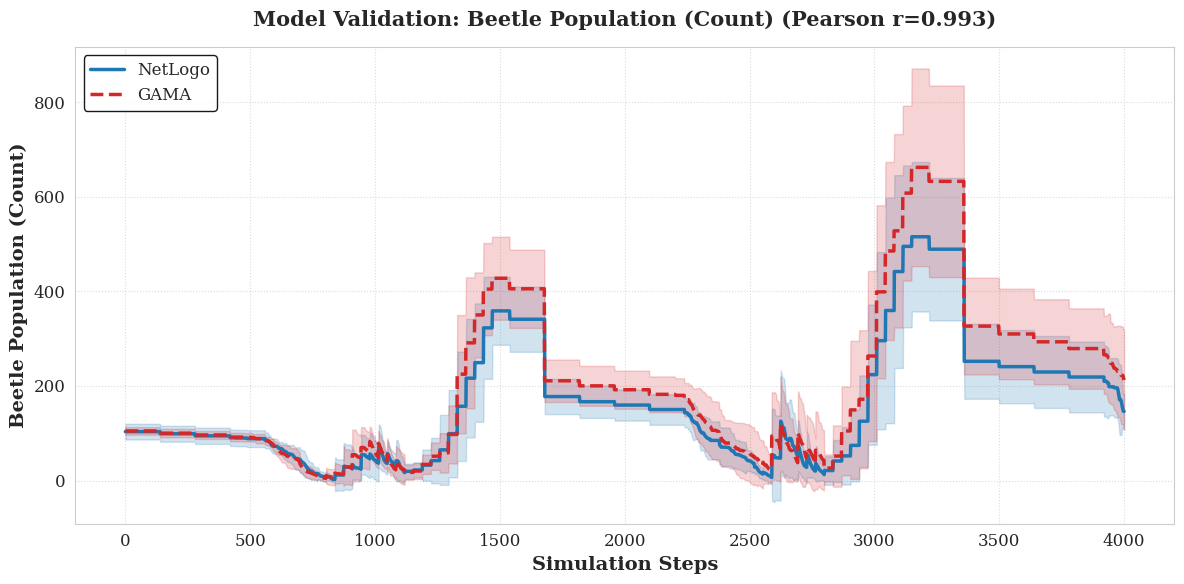


  Analyzing wood_damage...
    Pearson r=0.9947 | RMSE=615.97
    Saved plot: validation_results/validation_wood_damage.jpg


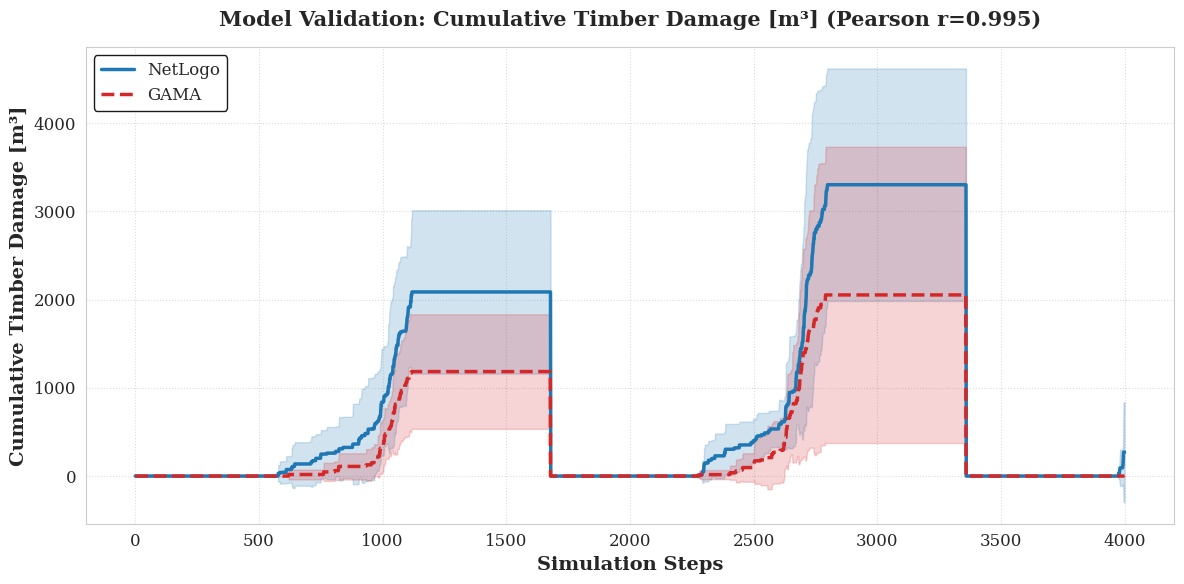


--- DONE ---


In [ ]:
"""
FIXED v8.1: NetLogo vs GAMA Validation
Includes a 'Line Cleaner' to fix double-quoted CSV formats.
Now displays plots inline before saving them in high scientific quality.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys
import os
import io

# Setup - Scientific Paper Style (IEEE)
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.size': 12,
    'font.family': 'serif', # Serifenschrift für akademischen Look
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 12
})

def debug_print(msg):
    print(msg)
    sys.stdout.flush()

# ============================================================================
# 1. SPECIALIZED NETLOGO LOADER
# ============================================================================

def load_netlogo_data(filepath):
    debug_print(f"\n--- Loading NetLogo: {filepath} ---")
    if not os.path.exists(filepath): return None

    # --- STEP 1: READ AND CLEAN RAW LINES MANUALLY ---
    cleaned_csv_buffer = io.StringIO()
    
    header_found = False
    row_count = 0
    
    try:
        with open(filepath, 'r', encoding='latin-1') as f:
            for line in f:
                line = line.strip()
                
                # 1. Skip garbage lines at the start until we find the header
                if not header_found:
                    if '[run number]' in line:
                        header_found = True
                        debug_print("  > Found header row. Starting cleanup...")
                    else:
                        continue 
                
                # 2. THE FIX: Strip outer quotes and fix double-double quotes
                if line.startswith('"') and line.endswith('"'):
                    line = line[1:-1]             
                    line = line.replace('""', '"') 
                
                # 3. Write clean line to our memory buffer
                cleaned_csv_buffer.write(line + "\n")
                row_count += 1
                
        debug_print(f"  > Cleaned {row_count} rows in memory.")
        cleaned_csv_buffer.seek(0)
        
    except Exception as e:
        debug_print(f"  ERROR reading file: {e}")
        return None

    if row_count == 0:
        debug_print("  CRITICAL: No relevant data found (Header '[run number]' never matched).")
        return None

    # --- STEP 2: LOAD FROM CLEANED MEMORY BUFFER ---
    try:
        df = pd.read_csv(cleaned_csv_buffer, sep=',')
        
        # Clean up column names
        df.columns = df.columns.str.replace('[', '').str.replace(']', '').str.replace('"', '').str.strip()
        debug_print(f"  > Detected Columns: {list(df.columns)}")

        # --- STEP 3: MAP COLUMNS ---
        rename_map = {
            'run number': 'run',
            'step': 'cycle',
            'count beetle': 'beetles',
            'sum Totmeter of patches': 'wood_damage',
            'Totmeter': 'wood_damage',
            'wood_damage': 'wood_damage'
        }
        df = df.rename(columns=rename_map)

        # --- STEP 4: FILTER AND CONVERT ---
        req_cols = ['run', 'cycle', 'beetles', 'wood_damage']
        available = [c for c in req_cols if c in df.columns]
        df = df[available]
        
        # Force Numeric
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
        df = df.dropna()
        
        debug_print(f"  > SUCCESS: Loaded {len(df)} rows.")
        return df

    except Exception as e:
        debug_print(f"  ERROR parsing cleaned data: {e}")
        return None

# ============================================================================
# 2. GAMA LOADER (Standard)
# ============================================================================

def load_gama_data(filepath):
    debug_print(f"\n--- Loading GAMA: {filepath} ---")
    if not os.path.exists(filepath): return None
        
    try:
        skip_count = 0
        with open(filepath, 'r', encoding='latin-1') as f:
            l1 = f.readline()
            l2 = f.readline()
            if "'" in l1 and "run_id" in l1 and "run_id" in l2:
                skip_count = 1
        
        df = pd.read_csv(filepath, skiprows=skip_count)
        if len(df) > 0 and str(df.iloc[0,0]) == 'run_id': df = df.iloc[1:]

        df = df.rename(columns={'run_id': 'run', 'step': 'cycle'})
        
        cols = ['run', 'cycle', 'beetles', 'wood_damage']
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        df = df.dropna()
        debug_print(f"  > Loaded {len(df)} rows.")
        return df

    except Exception as e:
        debug_print(f"  ERROR loading GAMA: {e}")
        return None

# ============================================================================
# 3. ANALYSIS & PLOTTING
# ============================================================================

def compare_models(nl_df, gama_df, output_dir='validation_results'):
    debug_print("\n--- Starting Comparison ---")
    Path(output_dir).mkdir(exist_ok=True)
    
    # Align
    max_cycle = min(nl_df['cycle'].max(), gama_df['cycle'].max())
    debug_print(f"  > Aligning data up to cycle {max_cycle}")
    
    nl_df = nl_df[nl_df['cycle'] <= max_cycle]
    gama_df = gama_df[gama_df['cycle'] <= max_cycle]
    
    metrics = ['beetles', 'wood_damage']
    
    for metric in metrics:
        debug_print(f"\n  Analyzing {metric}...")
        
        if metric not in nl_df.columns:
            debug_print(f"  MISSING in NetLogo: {metric}")
            continue
        if metric not in gama_df.columns:
            debug_print(f"  MISSING in GAMA: {metric}")
            continue
            
        nl_stats = nl_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        gama_stats = gama_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        
        # Stats
        r, p, rmse = 0, 0, 0
        if len(nl_stats) > 1 and len(gama_stats) > 1:
            if nl_stats['mean'].std() > 0 and gama_stats['mean'].std() > 0:
                r, p = stats.pearsonr(nl_stats['mean'], gama_stats['mean'])
            rmse = np.sqrt(((nl_stats['mean'] - gama_stats['mean']) ** 2).mean())
        
        debug_print(f"    Pearson r={r:.4f} | RMSE={rmse:.2f}")
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # NetLogo Plot (Blue)
        ax.plot(nl_stats['cycle'], nl_stats['mean'], label=f'NetLogo', color='#1f77b4', linewidth=2.5)
        ax.fill_between(nl_stats['cycle'], nl_stats['mean'] - nl_stats['std'], nl_stats['mean'] + nl_stats['std'], color='#1f77b4', alpha=0.2)
        
        # GAMA Plot (Red)
        ax.plot(gama_stats['cycle'], gama_stats['mean'], label='GAMA', color='#d62728', linestyle='--', linewidth=2.5)
        ax.fill_between(gama_stats['cycle'], gama_stats['mean'] - gama_stats['std'], gama_stats['mean'] + gama_stats['std'], color='#d62728', alpha=0.2)
        
        # Clean labels and title
        formatted_metric_name = "Beetle Population (Count)" if metric == 'beetles' else "Cumulative Timber Damage [m³]"
        ax.set_title(f'Model Validation: {formatted_metric_name} (Pearson r={r:.3f})', fontsize=15, fontweight='bold', pad=15)
        ax.set_xlabel('Simulation Steps', fontweight='bold')
        ax.set_ylabel(formatted_metric_name, fontweight='bold')
        
        ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        plt.tight_layout() # Verhindert abgeschnittene Labels
        
        # 1. Bild abspeichern (Hochauflösend)
        filename = f"{output_dir}/validation_{metric}.jpg" # Geändert auf .jpg
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        debug_print(f"    Saved plot: {filename}")
        
        # 2. BILD ANZEIGEN (Das ist die hinzugefügte Funktionalität!)
        plt.show() 
        
        # 3. Plot-Speicher leeren, damit sich der nächste Graph nicht überlagert
        plt.close()

if __name__ == "__main__":
    nl_file = "netlogo_results2_9000steps.csv"
    gama_file = "gama_results_combined.csv"
    
    nl_data = load_netlogo_data(nl_file)
    gama_data = load_gama_data(gama_file)
    
    if nl_data is not None and gama_data is not None:
        if not nl_data.empty and not gama_data.empty:
            compare_models(nl_data, gama_data)
            debug_print("\n--- DONE ---")
        else:
            debug_print("\nERROR: One of the dataframes is empty (0 rows).")


--- Loading GAMA: gama_results_combined.csv ---
  > Loaded 84000 rows.

--- Loading GAMA: gama_results_8400ticks_25x25.csv ---
  > Loaded 8349 rows.

--- Starting Resolution Comparison ---
  > Aligning data up to cycle 8399

  Analyzing beetles...
    Saved plot: validation_results/resolution_comparison_beetles.jpg


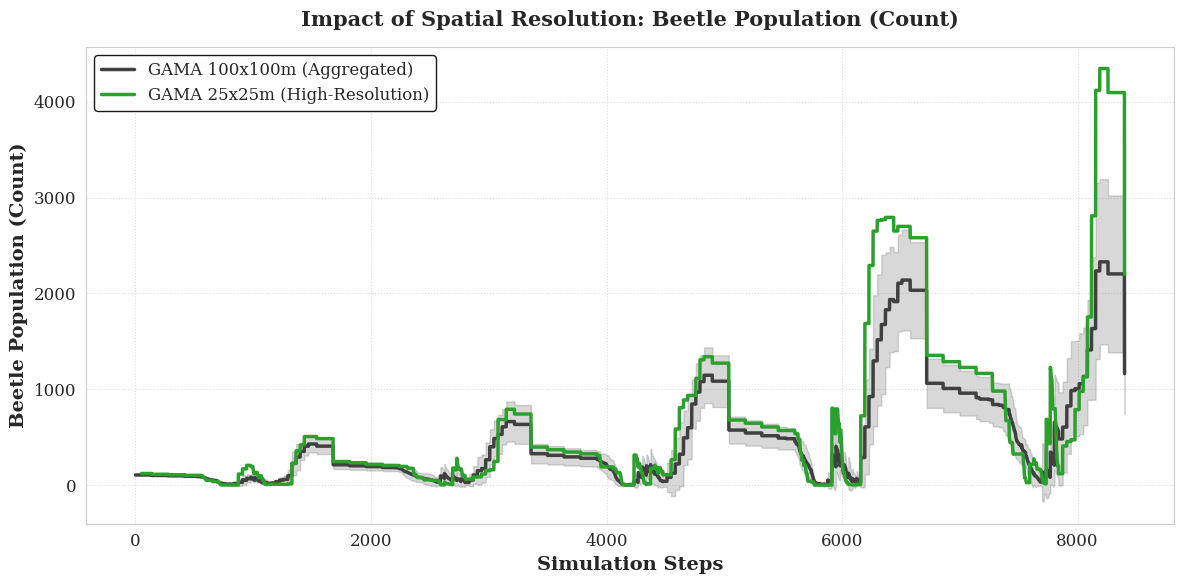


  Analyzing wood_damage...
    Saved plot: validation_results/resolution_comparison_wood_damage.jpg


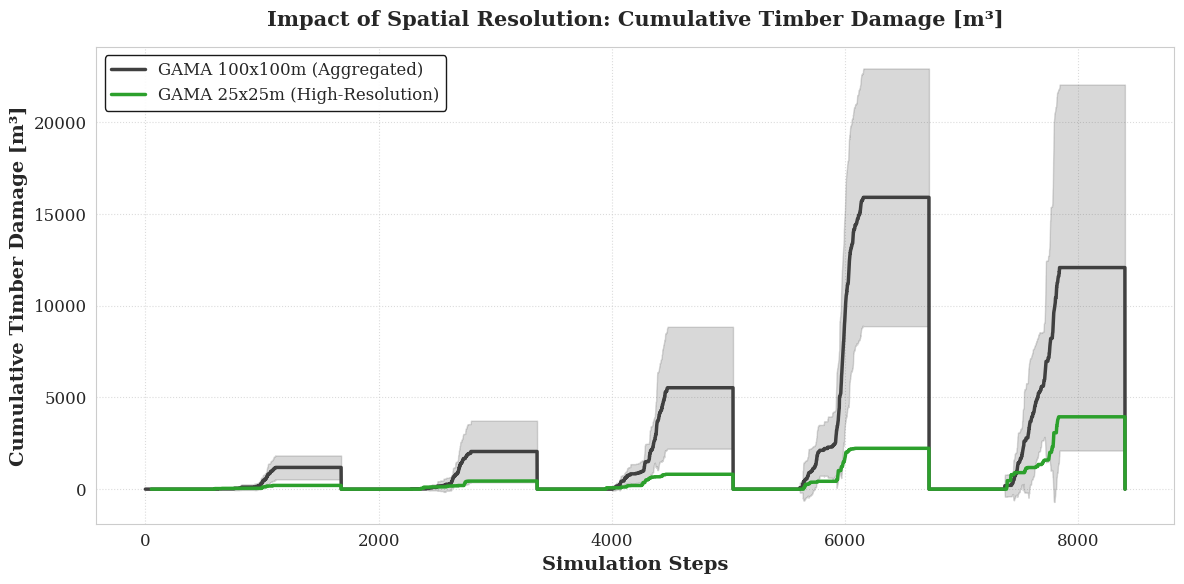


--- DONE ---


In [5]:
"""
Resolution Comparison: GAMA 100m vs GAMA 25m
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys
import os

# Setup - Scientific Paper Style (IEEE)
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.size': 12,
    'font.family': 'serif', 
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 12
})

def debug_print(msg):
    print(msg)
    sys.stdout.flush()

# ============================================================================
# GAMA LOADER
# ============================================================================

def load_gama_data(filepath):
    debug_print(f"\n--- Loading GAMA: {filepath} ---")
    if not os.path.exists(filepath): return None
        
    try:
        skip_count = 0
        with open(filepath, 'r', encoding='latin-1') as f:
            l1 = f.readline()
            l2 = f.readline()
            if "'" in l1 and "run_id" in l1 and "run_id" in l2:
                skip_count = 1
        
        df = pd.read_csv(filepath, skiprows=skip_count)
        if len(df) > 0 and str(df.iloc[0,0]) == 'run_id': df = df.iloc[1:]

        df = df.rename(columns={'run_id': 'run', 'step': 'cycle'})
        
        cols = ['run', 'cycle', 'beetles', 'wood_damage']
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        df = df.dropna()
        debug_print(f"  > Loaded {len(df)} rows.")
        return df

    except Exception as e:
        debug_print(f"  ERROR loading GAMA: {e}")
        return None

# ============================================================================
# ANALYSIS & PLOTTING: 100m vs 25m
# ============================================================================

def compare_resolutions(gama100_df, gama25_df, output_dir='validation_results'):
    debug_print("\n--- Starting Resolution Comparison ---")
    Path(output_dir).mkdir(exist_ok=True)
    
    # Align
    max_cycle = min(gama100_df['cycle'].max(), gama25_df['cycle'].max())
    debug_print(f"  > Aligning data up to cycle {max_cycle}")
    
    gama100_df = gama100_df[gama100_df['cycle'] <= max_cycle]
    gama25_df = gama25_df[gama25_df['cycle'] <= max_cycle]
    
    metrics = ['beetles', 'wood_damage']
    
    for metric in metrics:
        debug_print(f"\n  Analyzing {metric}...")
        
        stat100 = gama100_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        stat25 = gama25_df.groupby('cycle')[metric].agg(['mean', 'std']).reset_index()
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # 100m Plot (Grey/Black - representing the baseline)
        ax.plot(stat100['cycle'], stat100['mean'], label='GAMA 100x100m (Aggregated)', color='#404040', linewidth=2.5)
        ax.fill_between(stat100['cycle'], stat100['mean'] - stat100['std'], stat100['mean'] + stat100['std'], color='#404040', alpha=0.2)
        
        # 25m Plot (Green - representing high-res forest)
        ax.plot(stat25['cycle'], stat25['mean'], label='GAMA 25x25m (High-Resolution)', color='#2ca02c', linestyle='-', linewidth=2.5)
        ax.fill_between(stat25['cycle'], stat25['mean'] - stat25['std'], stat25['mean'] + stat25['std'], color='#2ca02c', alpha=0.2)
        
        # Clean labels and title
        formatted_metric_name = "Beetle Population (Count)" if metric == 'beetles' else "Cumulative Timber Damage [m³]"
        ax.set_title(f'Impact of Spatial Resolution: {formatted_metric_name}', fontsize=15, fontweight='bold', pad=15)
        ax.set_xlabel('Simulation Steps', fontweight='bold')
        ax.set_ylabel(formatted_metric_name, fontweight='bold')
        
        ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        plt.tight_layout()
        
        # Save and show
        filename = f"{output_dir}/resolution_comparison_{metric}.jpg"
        plt.savefig(filename, dpi=1200, bbox_inches='tight')
        debug_print(f"    Saved plot: {filename}")
        
        plt.show() 
        plt.close()

if __name__ == "__main__":
    file_100m = "gama_results_combined.csv"          # Dein alter Run
    #file_25m = "gama_results_combined25x25.csv"      # Dein neuer Run
    file_25m = "gama_results_8400ticks_25x25.csv"

    data_100m = load_gama_data(file_100m)
    data_25m = load_gama_data(file_25m)
    
    if data_100m is not None and data_25m is not None:
        if not data_100m.empty and not data_25m.empty:
            compare_resolutions(data_100m, data_25m)
            debug_print("\n--- DONE ---")
        else:
            debug_print("\nERROR: One of the dataframes is empty (0 rows).")